In [49]:
!pip install -U onnx onnxscript onnxruntime

In [50]:
# Imports

import torch
import torchvision.models as models
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import v2
from google.colab import files, drive
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import time
from datetime import timedelta

In [51]:
# Connect to drive and preliminary setup

drive.mount("/content/drive")
NOTEBOOK_DIR = "/content/drive/MyDrive/Colab Projects/Dog or Dough"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


In [52]:
# Define transfer learning architecture

model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)
model.classifier[3] = nn.Linear(in_features=1280, out_features=2)
model.to(device)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bi

In [53]:
# Data and preprocessing

# Define preprocessing as per https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v3_large.html#torchvision.models.MobileNet_V3_Large_Weights
class OnTheFlyAugmentations(nn.Module):
    def __init__(self):
        super().__init__()
        self.aug = v2.Compose([
            v2.RandomHorizontalFlip(p=0.5),
            v2.RandomRotation(10),
            v2.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ),
            v2.RandomPerspective(distortion_scale=0.2, p=0.2)
        ])

    def forward(self, img):
        return self.aug(img)

RESCALE_SIZE = 232
IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(RESCALE_SIZE, interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(IMAGE_SIZE),
    OnTheFlyAugmentations(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
val_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(RESCALE_SIZE, interpolation=v2.InterpolationMode.BILINEAR),
    v2.CenterCrop(IMAGE_SIZE),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

batch_size = 32

train_dataset = ImageFolder(NOTEBOOK_DIR + "/data/train/", train_transforms)
val_dataset = ImageFolder(NOTEBOOK_DIR + "/data/val/", val_transforms)
test_dataset = ImageFolder(NOTEBOOK_DIR + "/data/test/", val_transforms)

train_loader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

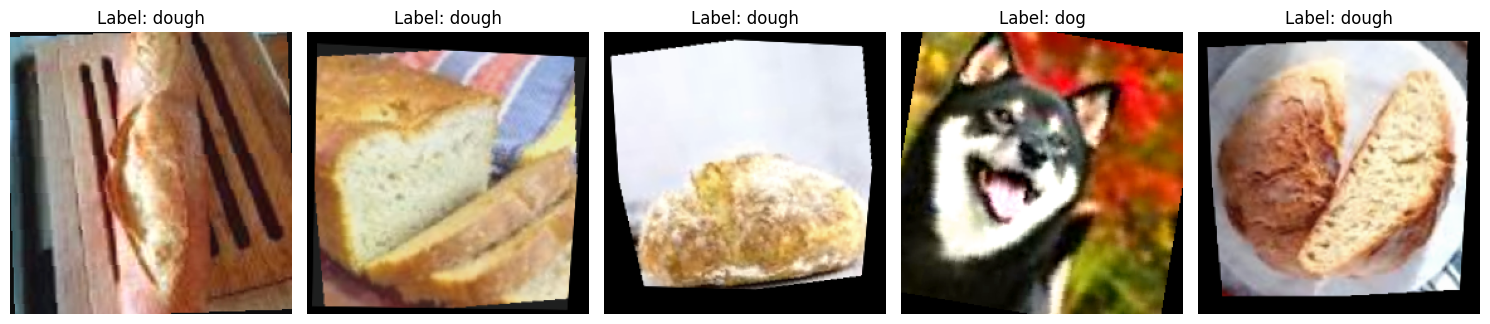

In [54]:
# Visualize training images

def unnormalize(x):
    return (x * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)).clamp(0, 1)

# Pick 5 random indices
indices = torch.randperm(len(train_dataset))[:5]
images = [train_dataset[i][0] for i in indices]
labels = [train_dataset[i][1] for i in indices]

plt.figure(figsize=(15,5))
for i in range(5):
    img = unnormalize(images[i]).permute(1,2,0).cpu()
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"Label: {train_dataset.classes[labels[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [55]:
# Define optimizer, scheduler, loss function, and training config

num_warmup_epochs = 10
num_epochs = 100
patience = 20

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1, total_iters=num_warmup_epochs)
main_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs - num_warmup_epochs, eta_min=1e-7)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, main_scheduler],
    milestones=[num_warmup_epochs]
)

criterion = nn.CrossEntropyLoss()

In [56]:
# Train helpers

def train_step(model, dataloader, loss_fn, optimizer):
    model.train()
    running_loss = 0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc="Train"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0) # total loss for curr batch
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    per_class_precision = precision_score(all_labels, all_preds, average=None)
    per_class_recall = recall_score(all_labels, all_preds, average=None)
    per_class_f1 = f1_score(all_labels, all_preds, average=None)

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    macro_precision = precision_score(all_labels, all_preds, average='macro')
    macro_recall = recall_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)

    train_loss = running_loss / len(train_loader.dataset) # avg loss of a sample over curr epoch
    
    print(f"Train Loss: {train_loss:.4f} | Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}, Macro Recall: {macro_recall:.4f}, Macro F1: {macro_f1:.4f}")
    for i, (p, r, f) in enumerate(zip(per_class_precision, per_class_recall, per_class_f1)):
        print(f"Class {train_dataset.classes[i]} -> Precision: {p:.4f}, Recall: {r:.4f}, F1: {f:.4f}")

    return train_loss

def val_step(model, dataloader, criterion,):
    model.eval()
    running_loss = 0

    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    per_class_precision = precision_score(all_labels, all_preds, average=None)
    per_class_recall = recall_score(all_labels, all_preds, average=None)
    per_class_f1 = f1_score(all_labels, all_preds, average=None)

    macro_precision = precision_score(all_labels, all_preds, average='macro')
    macro_recall = recall_score(all_labels, all_preds, average='macro')
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy = accuracy_score(all_labels, all_preds)

    val_loss = running_loss / len(val_loader.dataset)

    print(f"Validation Loss: {val_loss:.4f} | Accuracy: {accuracy:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}, Macro Recall: {macro_recall:.4f}, Macro F1: {macro_f1:.4f}")
    for i, (p, r, f) in enumerate(zip(per_class_precision, per_class_recall, per_class_f1)):
        print(f"Class {val_loader.dataset.classes[i]} -> Precision: {p:.4f}, Recall: {r:.4f}, F1: {f:.4f}")

    return val_loss, macro_f1


def plot_loss(train_losses, val_losses, save_path):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(10, 6))
    
    # Plot training loss with points
    plt.plot(epochs, train_losses, 'o-', label='Train Loss', color='blue', markersize=5)
    
    # Plot validation loss with points
    plt.plot(epochs, val_losses, 's-', label='Validation Loss', color='red', markersize=5)
    
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)
    
    plt.savefig(save_path)
    plt.close()

def export_model(model):
    dummy_input = torch.randn(1, 3, 224, 224).to(device)
    onnx_path = NOTEBOOK_DIR + "/model.onnx"

    model.eval()

    torch.onnx.export(
        model, 
        dummy_input, 
        onnx_path, 
        export_params=True,
        opset_version=18,
        do_constant_folding=True,
        input_names = ['input'],
        output_names = ['output'],
        dynamic_axes={'input' : {0 : 'batch_size'},
                    'output' : {0 : 'batch_size'}}
    )

    print(f"Model exported to ONNX at {onnx_path}")

In [57]:
# Training

best_f1 = 0
epochs_without_improvement = 0
train_losses = []
val_losses = []
epoch_times = []
for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()
    print(f"Epoch: {epoch}/{num_epochs}")
    print("-" * 30)

    train_loss = train_step(model, train_loader, criterion, optimizer)
    val_loss, val_f1 = val_step(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    plot_loss(train_losses, val_losses, NOTEBOOK_DIR + "/loss_curve.png")

    epoch_times.append(time.time() - epoch_start)
    avg_time = sum(epoch_times) / len(epoch_times)
    eta = avg_time * (num_epochs - epoch)
    print(f"ETA: {str(timedelta(seconds=int(eta)))}")

    if val_f1 > best_f1:
        epochs_without_improvement = 0
        best_f1 = val_f1
        print(f"Best epoch: {epoch}")
        torch.save(model.state_dict(), NOTEBOOK_DIR + "/best_ckpt.pth")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print("Early stopping triggered")
            break
    print(f"Patience: {epochs_without_improvement}/{patience}")


export_model(model)

Epoch: 1/100
------------------------------


Train: 100%|██████████| 143/143 [00:16<00:00,  8.71it/s]


Train Loss: 0.4383 | Accuracy: 0.8588
Macro Precision: 0.8593, Macro Recall: 0.8587, Macro F1: 0.8588
Class dog -> Precision: 0.8707, Recall: 0.8406, F1: 0.8554
Class dough -> Precision: 0.8479, Recall: 0.8768, F1: 0.8621


Validation: 100%|██████████| 61/61 [00:02<00:00, 22.95it/s]


Validation Loss: 0.1467 | Accuracy: 0.9846
Macro Precision: 0.9851, Macro Recall: 0.9845, Macro F1: 0.9846
Class dog -> Precision: 0.9989, Recall: 0.9701, F1: 0.9843
Class dough -> Precision: 0.9713, Recall: 0.9990, F1: 0.9849
ETA: 0:31:46
Best epoch: 1
Patience: 0/20
Epoch: 2/100
------------------------------


...

Train Loss: 0.0011 | Accuracy: 1.0000
Macro Precision: 1.0000, Macro Recall: 1.0000, Macro F1: 1.0000
Class dog -> Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Class dough -> Precision: 1.0000, Recall: 1.0000, F1: 1.0000


Validation: 100%|██████████| 61/61 [00:02<00:00, 24.47it/s]
/tmp/ipython-input-3798514349.py:112: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


Validation Loss: 0.0033 | Accuracy: 0.9990
Macro Precision: 0.9990, Macro Recall: 0.9990, Macro F1: 0.9990
Class dog -> Precision: 1.0000, Recall: 0.9979, F1: 0.9990
Class dough -> Precision: 0.9980, Recall: 1.0000, F1: 0.9990
ETA: 0:18:30
Early stopping triggered


W0216 21:47:36.734000 435 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0216 21:47:36.736000 435 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0216 21:47:36.737000 435 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0216 21:47:36.739000 435 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 92 of general pattern rewrite rules.
Model exported to ONNX at /content/drive/MyDrive/Colab Projects/Dog or Dough/model.onnx


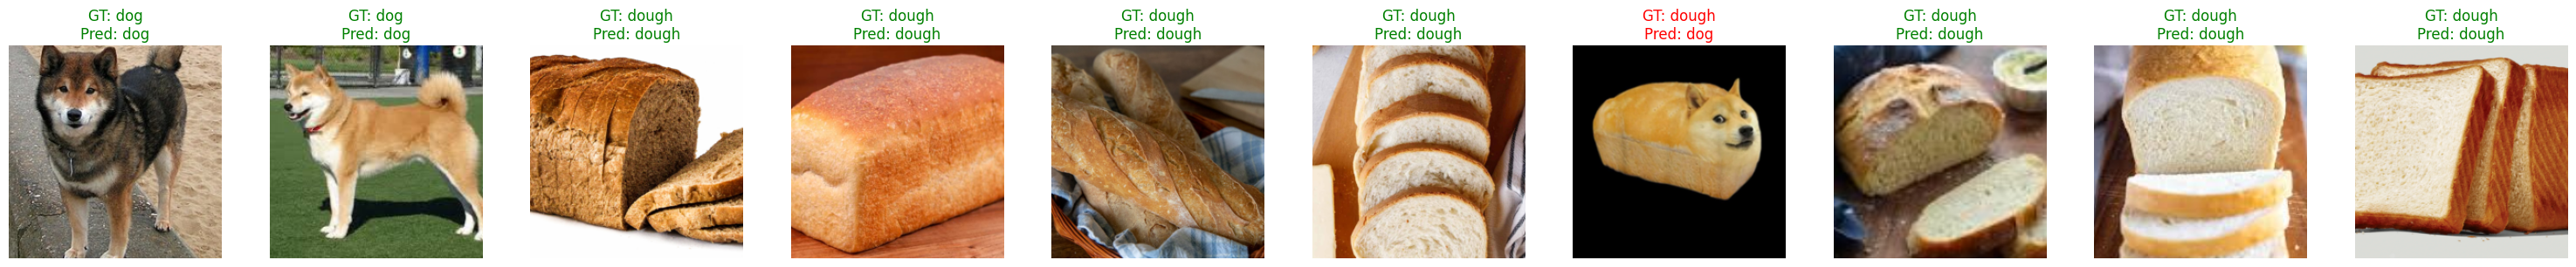

In [58]:
state_dict = torch.load(NOTEBOOK_DIR + "/best_ckpt.pth", map_location=device)
model.load_state_dict(state_dict)
model.eval()
def visualize_predictions(model, dataloader, class_names, num_images=8, device='cuda'):
    """
    Visualize images and predictions from a model and a DataLoader.
    """
    model.eval()
    
    images, labels = next(iter(dataloader))
    images = images.to(device)
    labels = labels.to(device)
    
    with torch.inference_mode():
        outputs = model(images)
        preds = outputs.argmax(dim=1)
    
    images = images.cpu()
    labels = labels.cpu()
    preds = preds.cpu()
    
    mean = torch.tensor(IMAGENET_MEAN, dtype=images.dtype).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD, dtype=images.dtype).view(3,1,1)
    
    k = min(num_images, images.size(0))
    plt.figure(figsize=(3*k, 3))
    
    for i in range(k):
        img = (images[i] * std + mean).clamp(0,1).permute(1,2,0)
        gt = class_names[labels[i]]
        pred = class_names[preds[i]]
        color = 'green' if gt == pred else 'red'
        
        plt.subplot(1, k, i+1)
        plt.imshow(img)
        plt.title(f"GT: {gt}\nPred: {pred}", color=color)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader, test_dataset.classes, 10)